<a href="https://colab.research.google.com/github/alpotj/datascientist/blob/master/Projet_NLP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importer les bibliotheque necessaire

In [2]:
#les bibliotheque utiliser
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, DistilBertTokenizer, DistilBertForSequenceClassification, CamembertTokenizer, CamembertForSequenceClassification, Trainer, TrainingArguments
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re


In [3]:
!nvidia-smi

Wed May 21 12:06:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             12W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Téléchargement des ressources NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Creation de dataset Synthétique

In [5]:
# Creation de dataset Synthétique
# Mettre à jour la liste des colonnes dans la fonction create_synthetic_dataset
def create_synthetic_dataset(n_samples=10000):
    biomes = ['Forêt tropicale', 'Désert', 'Prairie', 'Toundra', 'Forêt boréale']
    descriptions = {
        'Forêt tropicale': ['pluies fréquentes', 'végétation luxuriante', 'biodiversité riche', 'climat humide', 'forêts denses', 'faune exotique', 'canopée épaisse', 'rivières abondantes', 'sols fertiles', 'humidité élevée'],
        'Désert': ['sable aride', 'précipitations rares', 'plantes succulentes', 'chaleur extrême', 'oasis rares', 'vents secs', 'dunes imposantes', 'ciel dégagé', 'nuits fraîches', 'sol rocailleux'],
        'Prairie': ['herbes dominantes', 'climat sec', 'animaux herbivores', 'sols riches', 'paysages ouverts', 'feux saisonniers', 'vents constants', 'biodiversité modérée', 'prairies verdoyantes', 'saisons marquées'],
        'Toundra': ['froid glacial', 'sol gelé', 'plantes basses', 'hivers prolongés', 'pergélisol', 'faune adaptée', 'lumière polaire', 'sol pauvre', 'vents polaires', 'toundra aride'],
        'Forêt boréale': ['conifères abondants', 'climat froid', 'sols acides', 'longs hivers', 'taïga', 'neige abondante', 'faune nordique', 'lacs gelés', 'forêts résineuses', 'étés courts']
    }
    biome_params = {
        'Forêt tropicale': {'temp_mean': 25, 'temp_std': 3, 'pluv_mean': 2000, 'pluv_std': 500},
        'Désert': {'temp_mean': 30, 'temp_std': 5, 'pluv_mean': 100, 'pluv_std': 50},
        'Prairie': {'temp_mean': 15, 'temp_std': 4, 'pluv_mean': 600, 'pluv_std': 200},
        'Toundra': {'temp_mean': -10, 'temp_std': 5, 'pluv_mean': 200, 'pluv_std': 100},
        'Forêt boréale': {'temp_mean': 0, 'temp_std': 4, 'pluv_mean': 400, 'pluv_std': 150}
    }

    data = []
    for _ in range(n_samples):
        biome = np.random.choice(biomes)
        desc = ' '.join(np.random.choice(descriptions[biome], size=3)) + ' ' + ' '.join(np.random.choice(['nature', 'environnement', 'climat', 'faune', 'flore', 'écosystème', 'biodiversité', 'conservation'], size=2))
        temp = np.random.normal(biome_params[biome]['temp_mean'], biome_params[biome]['temp_std'])
        pluv = np.random.normal(biome_params[biome]['pluv_mean'], biome_params[biome]['pluv_std'])
        data.append([desc, biome, temp, pluv])
    # Mettre à jour la liste des colonnes pour qu'elle corresponde aux 4 éléments dans 'data'
    return pd.DataFrame(data, columns=['description', 'biome', 'temperature', 'precipitation'])

In [6]:
# Générer le dataset
# Mettre à jour les noms de colonnes pour inclure 'temp' et 'pluv'
df = create_synthetic_dataset(n_samples=10000)
print("Dataset synthétique basé sur les biomes :")
print(df.head())

Dataset synthétique basé sur les biomes :
                                         description          biome  \
0  animaux herbivores animaux herbivores sols ric...        Prairie   
1  sol pauvre plantes basses sol pauvre environne...        Toundra   
2  dunes imposantes précipitations rares sol roca...         Désert   
3  ciel dégagé chaleur extrême plantes succulente...         Désert   
4  lacs gelés lacs gelés climat froid conservatio...  Forêt boréale   

   temperature  precipitation  
0    20.248544     684.624530  
1    -5.195767     225.077912  
2    29.623961     192.511107  
3    22.033887      81.666087  
4    -6.357605     382.136925  


Prétraitement NLP

In [7]:
#  Nettoyage des données textuelles (NLP Preprocessing)
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('french'))
    tokens = [t for t in tokens if t not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['cleaned_description'] = df['description'].apply(preprocess_text)
print("\nExemple de texte nettoyé :")
print(df[['description', 'cleaned_description']].head())


Exemple de texte nettoyé :
                                         description  \
0  animaux herbivores animaux herbivores sols ric...   
1  sol pauvre plantes basses sol pauvre environne...   
2  dunes imposantes précipitations rares sol roca...   
3  ciel dégagé chaleur extrême plantes succulente...   
4  lacs gelés lacs gelés climat froid conservatio...   

                                 cleaned_description  
0  animaux herbivore animaux herbivore sol rich é...  
1  sol pauvre plantes bass sol pauvre environneme...  
2  dune imposantes précipitations rares sol rocai...  
3  ciel dégagé chaleur extrême plantes succulente...  
4  lac gelés lac gelés climat froid conservation ...  


Tokenisation et Préparation

In [8]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=len(df['biome'].unique()))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
# Encodage des labels
label_map = {biome: idx for idx, biome in enumerate(df['biome'].unique())}
df['label'] = df['biome'].map(label_map)

# Séparation train/test
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['cleaned_description'], df['label'], test_size=0.2, random_state=42
)

In [10]:
# Tokenisation pour BERT
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)



Dataset PyTorch

In [11]:
# Création du dataset pour PyTorch
class BiomeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = BiomeDataset(train_encodings, train_labels.values)
test_dataset = BiomeDataset(test_encodings, test_labels.values)


 Entraînement

In [12]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import wandb

# Connexion à Weights & Biases (optionnel mais recommandé)
wandb.login()

# Configuration des arguments d'entraînement
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    # Renommé evaluation_strategy en eval_strategy
    eval_strategy='epoch',  # évaluation à chaque epoch
    # Renommé save_strategy en save_strategy
    save_strategy='epoch',        # sauvegarde aussi à chaque epoch
    report_to="wandb",            # activation de Weights & Biases
    run_name="bert-text-classification",  # nom du run dans wandb
)

# Fonction de métriques
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

#Initialisation du Trainer
from transformers import DataCollatorWithPadding

#Data collator qui remplace `tokenizer=...`
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,        #
    compute_metrics=compute_metrics,
)


#  Entraînement
trainer.train()
#Sauvegarde du modèle et du tokenizer
output_dir = "./saved_model"
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: alpotj09 (alpotj09-institution) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.000300,0.000213,1.000000,1.000000,1.000000,1.000000
2,0.000100,0.000084,1.000000,1.000000,1.000000,1.000000
3,0.000100,0.000063,1.000000,1.000000,1.000000,1.000000


('./saved_model/tokenizer_config.json',
 './saved_model/special_tokens_map.json',
 './saved_model/vocab.txt',
 './saved_model/added_tokens.json')

 Évaluation

In [13]:
# Évaluation quantitative
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels.values

accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')

print("\nRésultats d'évaluation quantitative :")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score macro : {f1_macro:.4f}")
print(f"F1-score micro : {f1_micro:.4f}")



Résultats d'évaluation quantitative :
Accuracy : 1.0000
F1-score macro : 1.0000
F1-score micro : 1.0000


 Visualisations

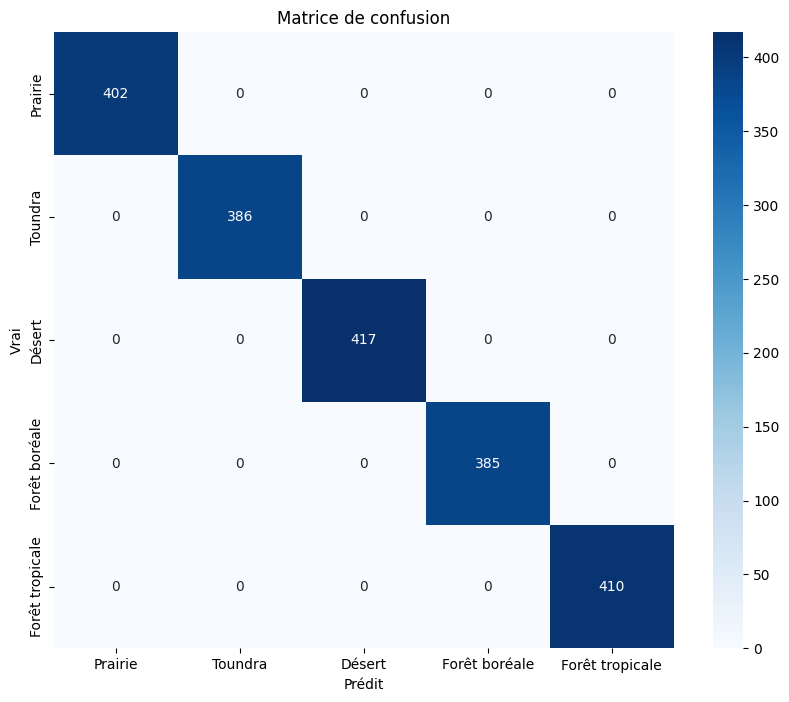

In [14]:
# Matrice de confusion (Heatmap)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.show()

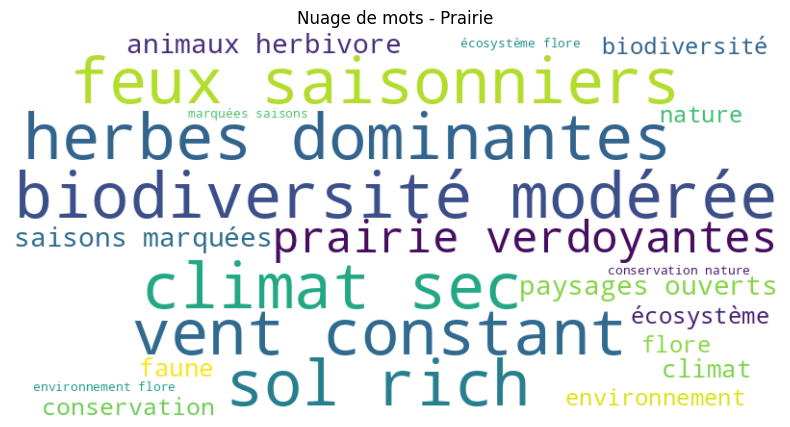

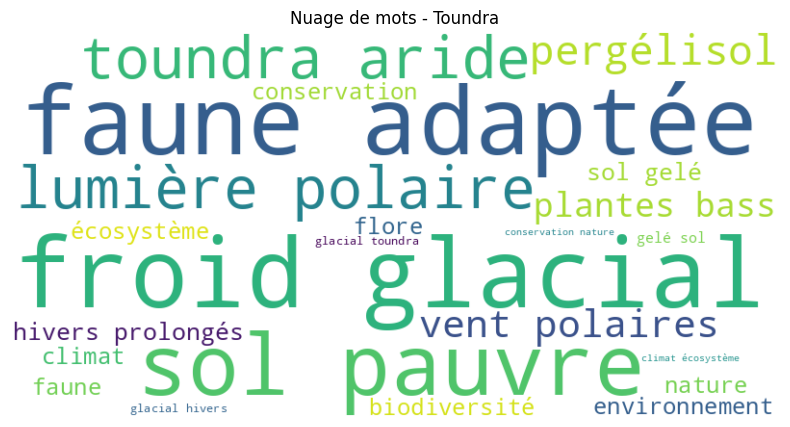

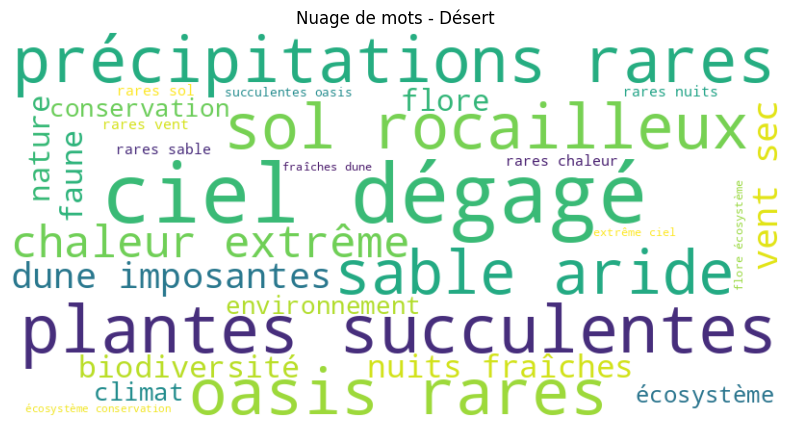

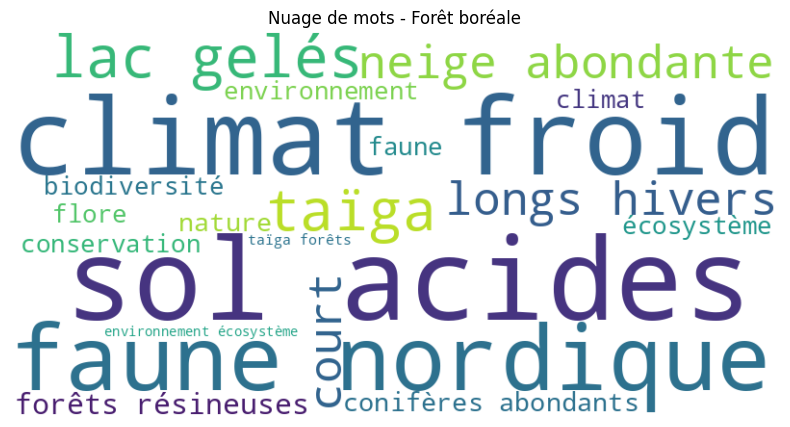

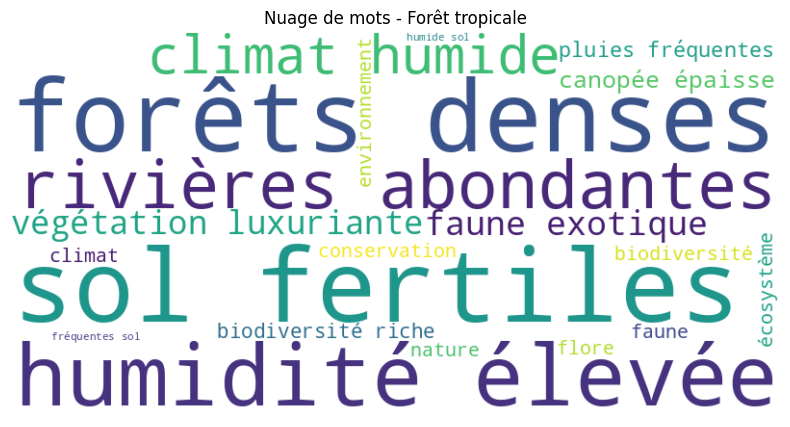

In [15]:
# Nuages de mots par classe
for biome in df['biome'].unique():
    words = ' '.join(df[df['biome'] == biome]['cleaned_description'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(words)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nuage de mots - {biome}')
    plt.savefig(f'wordcloud_{biome}.png')
    plt.show()

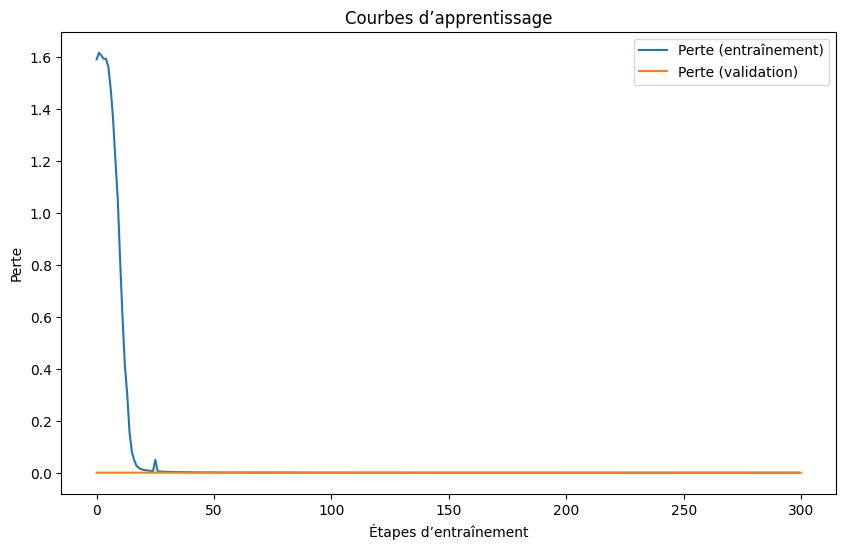

In [16]:
# Courbes d’apprentissage (loss)
train_logs = trainer.state.log_history
train_loss = [log['loss'] for log in train_logs if 'loss' in log]
eval_loss = [log['eval_loss'] for log in train_logs if 'eval_loss' in log]
steps = range(len(train_loss))

plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, label='Perte (entraînement)')
plt.plot(np.linspace(0, len(train_loss), len(eval_loss)), eval_loss, label='Perte (validation)')
plt.xlabel('Étapes d’entraînement')
plt.ylabel('Perte')
plt.title('Courbes d’apprentissage')
plt.legend()
plt.savefig('learning_curves.png')
plt.show()